In [128]:
import sys
sys.path.append("/project/src")

In [129]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from sksurv.metrics import integrated_brier_score, cumulative_dynamic_auc, brier_score
from sklearn.metrics import mean_squared_error
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from preprocessing import (
    split_features_target,
    low_missingness_complete_case_analysis,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)
from helpers import (
  save_pic,
  show_pic,
  define_strata
)

import wandb
import joblib

In [130]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
    test_df_csv = "/content/drive/MyDrive/bachelor/nacc_test.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"
    test_df_csv = "./data/nacc_test.csv"

In [131]:
train_df = pd.read_csv(train_df_csv, delimiter=',')
test_df = pd.read_csv(test_df_csv, delimiter=',')

/tmp/ipykernel_2242/2510053026.py:2: DtypeWarning: Columns (4,8,27,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,190,193,195,201,203,205,207,209,211,217,219,223,227,233,235,237,245,370,372,394,405,545,576,601,672,689,706,760,763,805,813,814,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(test_df_csv, delimiter=',')


In [132]:
test_df = define_strata(test_df)

In [133]:
train_df.shape

(6484, 142)

In [134]:
test_df.shape

(3496, 857)

In [135]:
train_X, train_y = split_features_target(train_df)

# Cross-Validation results

In [136]:
cox_pipeline = joblib.load("joblib-storage/cox_best_pipeline.joblib")
preprocessor = cox_pipeline.named_steps['preprocessor']
cox = cox_pipeline.named_steps['model']

In [137]:
cv_cindex = joblib.load("joblib-storage/cox_best_cv_cindex.joblib")
cv_cindex_std = joblib.load("joblib-storage/cox_best_cv_cindex_std.joblib")
print(f"Best CV C-index: {cv_cindex:.4f} ± {cv_cindex_std:.4f}")

Best CV C-index: 0.7705 ± 0.0252


# Evaluaition on test dataset

In [138]:
fitted_low_missingness_cols = preprocessor.get_low_missingness_cols()
test_preprepared_df = low_missingness_complete_case_analysis(test_df, low_missingness_columns=fitted_low_missingness_cols)
test_X_raw, test_y = split_features_target(test_preprepared_df)
test_X = preprocessor.transform(test_X_raw)

Complete-case analysis on low-missing columns
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [139]:
test_events = test_y[SURVIVAL_EVENT_COL].astype(bool)
test_times = test_y[SURVIVAL_TIME_COL]

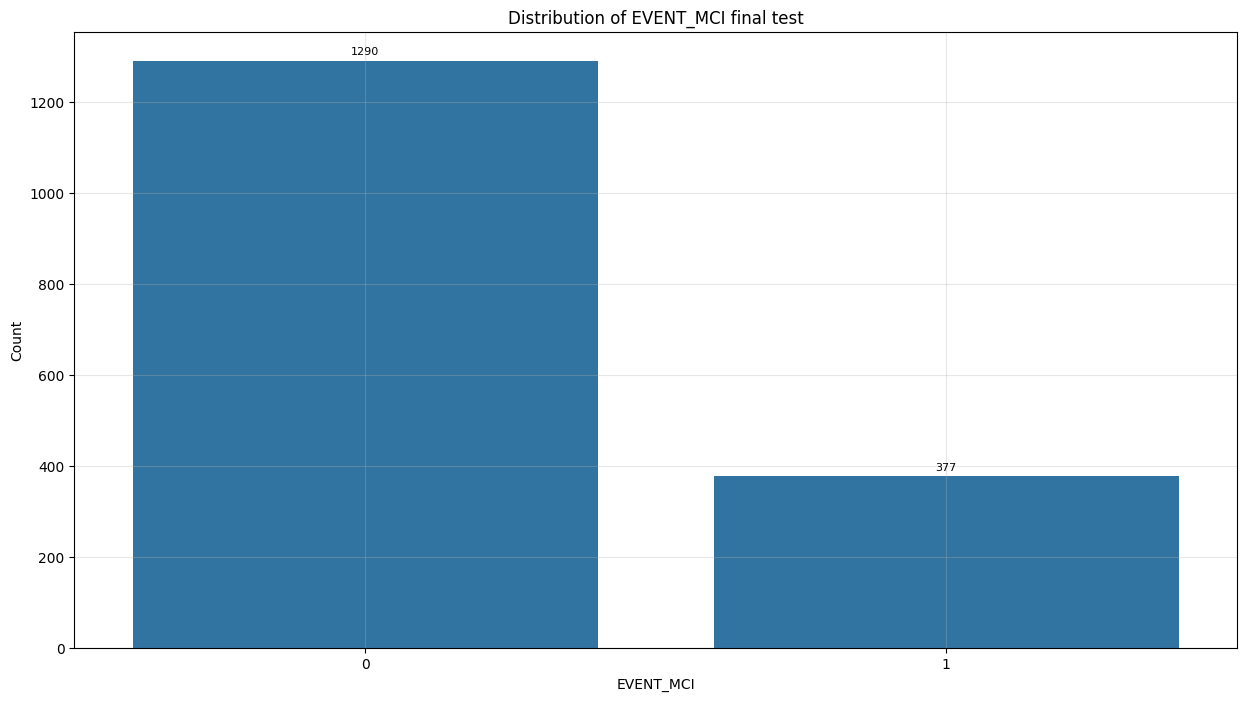

In [140]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=test_preprepared_df['EVENT_MCI'].value_counts().index, y=test_preprepared_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI final test')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [141]:
test_preprepared_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.773845
1    0.226155
Name: proportion, dtype: float64

In [142]:
test_X.shape

(1667, 293)

## Test c-index

In [143]:
cindex_test = cox.score(test_X, test_y)
print(f"Test C-index: {cindex_test:.4f}")

Test C-index: 0.7689


## Test IBS

In [144]:
def calculate_ibs(cox, test_X, test_y, event_min_time, event_max_time):
    times_ibs = np.linspace(event_min_time, event_max_time, 100)

    surv_probs_by_time = cox.predict_survival_function(test_X, times=times_ibs)
    # IBS expect matric in format (n_patients, n_timepoints), so we need to transpose the matrix
    T_surv_matrix = surv_probs_by_time.values.T

    ibs = integrated_brier_score(train_y, test_y, T_surv_matrix, times_ibs)
    print(f"Integrated Brier Score: {ibs:.4f}")

    return ibs

In [145]:
event_min_time = test_times[test_events].min()
event_max_time = test_times[test_events].max()
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

Event times range from 0.82 to 18.17 years


In [146]:
follow_up_ibs = calculate_ibs(cox, test_X, test_y, event_min_time, event_max_time)

Integrated Brier Score: 0.2324


In [147]:
event_min_time = test_times[test_events].min()
event_max_time = 5
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

ibs_5_years = calculate_ibs(cox, test_X, test_y, event_min_time, event_max_time)

Event times range from 0.82 to 5.00 years
Integrated Brier Score: 0.1084


## Test KM and Survival curve

In [148]:
kmf = KaplanMeierFitter()
kmf.fit(test_times, event_observed=test_events)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1667 total observations, 1290 right-censored observations>

In [149]:
predicted_surv = cox.predict_survival_function(test_X).mean(axis=1)
predicted_surv.head(5)

0.145    0.999782
0.468    0.999624
0.652    0.999624
0.690    0.999249
0.726    0.999090
dtype: float64

In [150]:
test_times_min = test_times.min()
test_times_max = test_times.max()
times_to_plot = np.linspace(test_times_min, test_times_max, 100)

In [151]:
brier_times = np.arange(int(test_times_min)+1, int(test_times_max)+1)
brier_score_df = cox.predict_survival_function(test_X, times=brier_times)
brier_scores_T = brier_score_df.values.T

_, brier_scores = brier_score(train_y, test_y, brier_scores_T, brier_times)
brier_scores

array([0.01249193, 0.07752285, 0.11267928, 0.15034477, 0.17266905,
       0.19057216, 0.20486468, 0.22367074, 0.23759904, 0.26102587,
       0.27276777, 0.28805643, 0.30614528, 0.33624611, 0.31822054,
       0.29064553, 0.30672211, 0.32504873, 0.16952508])

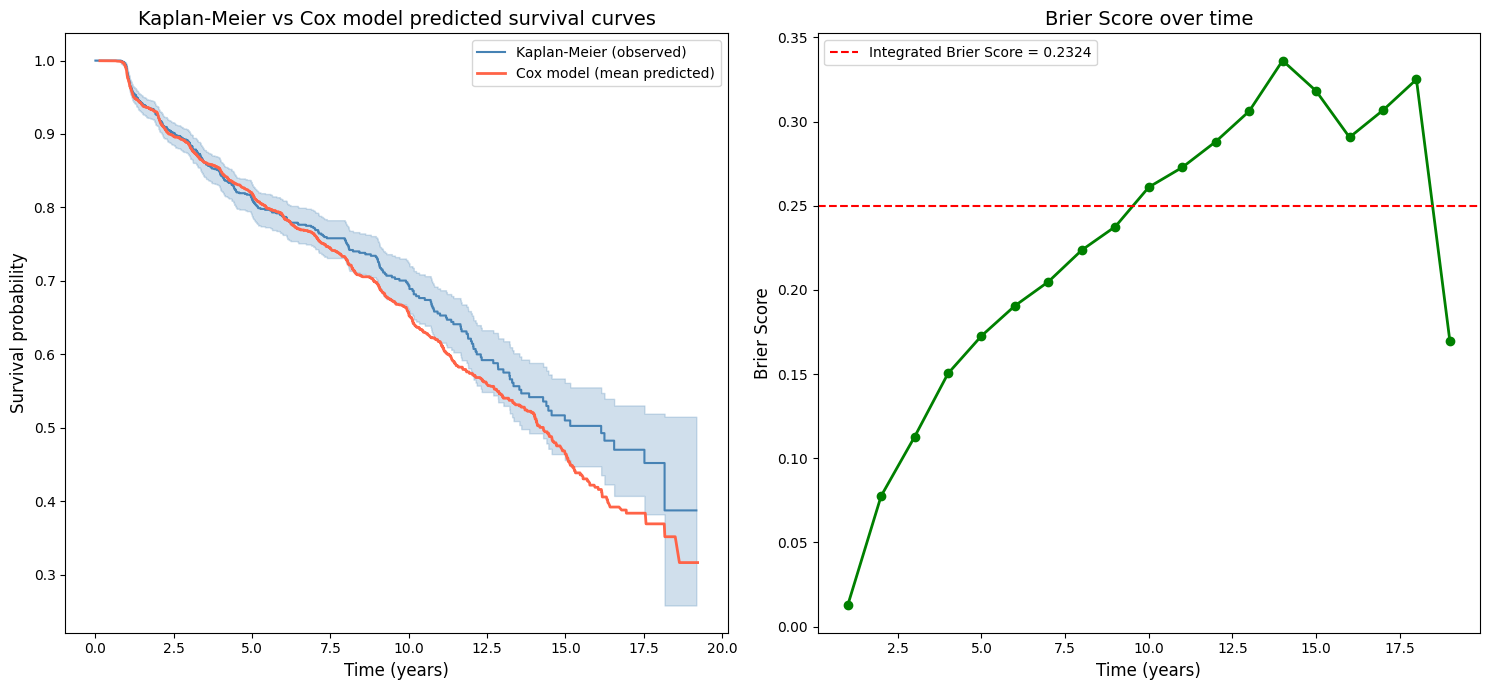

In [152]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
kmf.plot_survival_function(ax=ax[0], label="Kaplan-Meier (observed)", color="steelblue")
ax[0].plot(predicted_surv.index, predicted_surv.values, color="tomato", linewidth=2, label="Cox model (mean predicted)")
ax[0].set_xlabel("Time (years)", fontsize=12)
ax[0].set_ylabel("Survival probability", fontsize=12)
ax[0].set_title("Kaplan-Meier vs Cox model predicted survival curves", fontsize=14)
ax[0].legend()  

ax[1].plot(brier_times, brier_scores, color="green", marker="o", linewidth=2)
ax[1].axhline(0.25, color="red", linestyle="--", label=f"Integrated Brier Score = {follow_up_ibs:.4f}")
ax[1].set_xlabel("Time (years)", fontsize=12)
ax[1].set_ylabel("Brier Score", fontsize=12)
ax[1].set_title("Brier Score over time", fontsize=14)
ax[1].legend()
plt.tight_layout()
save_pic(plt, "cox_evaluation_KM_IBS.png")
plt.show()

In [153]:
times = np.linspace(test_times_min, test_times_max, 100)
pred_surv = cox.predict_survival_function(test_X, times=times).values.T
predicted_mean = np.mean(pred_surv, axis=0)
kmf_surv_scores = kmf.survival_function_at_times(times).values

abs_errors = np.abs(kmf_surv_scores - predicted_mean)

rmse      = np.sqrt(mean_squared_error(kmf_surv_scores, predicted_mean))
median_ae = np.median(abs_errors)
mean_ae   = np.mean(abs_errors)

print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

RMSE:             0.0430
Median Abs Error: 0.0312
Mean Abs Error:   0.0329


## Risk groups

In [209]:
LOW_RISK_GROUP_INDICATOR = 0
MEDIUM_RISK_GROUP_INDICATOR = 1
HIGH_RISK_GROUP_INDICATOR = 2

def assign_patient_to_risk_group(score, low_cutoff, high_cutoff):
    if score <= low_cutoff:
        return LOW_RISK_GROUP_INDICATOR
    elif score <= high_cutoff:
        return MEDIUM_RISK_GROUP_INDICATOR
    else:
        return HIGH_RISK_GROUP_INDICATOR

In [210]:
risk_scores = cox.predict_partial_hazard(test_X).values

risk_df = pd.DataFrame({
    "scores":     risk_scores,
    "event":      test_y[SURVIVAL_EVENT_COL].astype(bool),
    "duration":   test_y[SURVIVAL_TIME_COL],
})

low_medium_cutoff = np.percentile(risk_df["scores"], 33.333)
medium_high_cutoff = np.percentile(risk_df["scores"], 66.667)

risk_df["risk_group"] = risk_df["scores"].apply(
    lambda s: assign_patient_to_risk_group(s, low_medium_cutoff, medium_high_cutoff)
)

print(f"Cutoffs: low/medium={low_medium_cutoff:.3f}, medium/high={medium_high_cutoff:.3f}")
print(f"Low risk group:    {(risk_df['risk_group'] == LOW_RISK_GROUP_INDICATOR).sum()} patients")
print(f"Medium risk group: {(risk_df['risk_group'] == MEDIUM_RISK_GROUP_INDICATOR).sum()} patients")
print(f"High risk group:   {(risk_df['risk_group'] == HIGH_RISK_GROUP_INDICATOR).sum()} patients")


Cutoffs: low/medium=0.694, medium/high=1.277
Low risk group:    556 patients
Medium risk group: 555 patients
High risk group:   556 patients


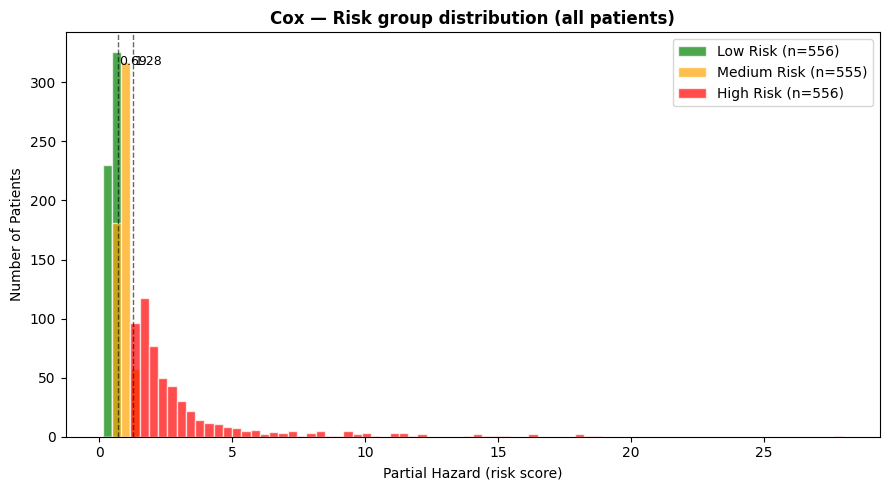

In [ ]:
NUMBER_OF_BINS = 80
bin_edges = np.linspace(risk_df["scores"].min(), risk_df["scores"].max(), NUMBER_OF_BINS + 1)

low_scores    = risk_df.loc[risk_df["risk_group"] == LOW_RISK_GROUP_INDICATOR, "scores"].values
medium_scores = risk_df.loc[risk_df["risk_group"] == MEDIUM_RISK_GROUP_INDICATOR, "scores"].values
high_scores   = risk_df.loc[risk_df["risk_group"] == HIGH_RISK_GROUP_INDICATOR, "scores"].values

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(low_scores,    bins=bin_edges, color="green",  label=f"Low Risk (n={len(low_scores)})",    edgecolor="white", alpha=0.7)
ax.hist(medium_scores, bins=bin_edges, color="orange", label=f"Medium Risk (n={len(medium_scores)})", edgecolor="white", alpha=0.7)
ax.hist(high_scores,   bins=bin_edges, color="red",    label=f"High Risk (n={len(high_scores)})",   edgecolor="white", alpha=0.7)

ax.axvline(low_medium_cutoff,  color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(medium_high_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
ymax = ax.get_ylim()[1]
ax.text(low_medium_cutoff + 0.05,  ymax * 0.92, f'{low_medium_cutoff:.2f}',  fontsize=9)
ax.text(medium_high_cutoff + 0.05, ymax * 0.92, f'{medium_high_cutoff:.2f}', fontsize=9)

ax.set_xlabel("Partial Hazard (risk score)", fontsize=10)
ax.set_ylabel("Number of Patients", fontsize=10)
ax.set_title("Cox — Risk group distribution (all patients)", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
save_pic(plt, "cox_evaluation_Risk_Groups.png")
plt.show()


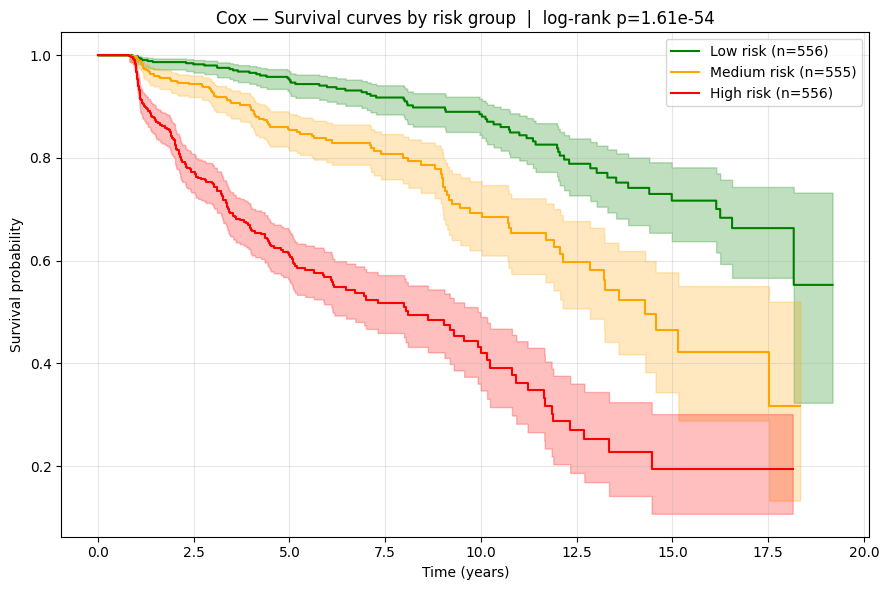

In [212]:
overall = multivariate_logrank_test(
    risk_df['duration'],
    risk_df['risk_group'],
    risk_df['event']
)

fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    LOW_RISK_GROUP_INDICATOR:    {"color": 'green',  "name": "Low risk"},
    MEDIUM_RISK_GROUP_INDICATOR: {"color": 'orange', "name": "Medium risk"},
    HIGH_RISK_GROUP_INDICATOR:   {"color": 'red',    "name": "High risk"}
}
kmf = KaplanMeierFitter()

for group in [LOW_RISK_GROUP_INDICATOR, MEDIUM_RISK_GROUP_INDICATOR, HIGH_RISK_GROUP_INDICATOR]:
    mask = risk_df['risk_group'] == group
    kmf.fit(
        risk_df.loc[mask, 'duration'],
        risk_df.loc[mask, 'event'],
        label=f'{colors[group]["name"]} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[group]["color"])

ax.set_xlabel("Time (years)")
ax.set_ylabel("Survival probability")
ax.set_title(f"Cox — Survival curves by risk group  |  log-rank p={overall.p_value:.2e}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_pic(plt, "cox_evaluation_Risk_Groups_KM.png")
plt.show()

In [ ]:
min_test_times = test_times.min()
max_test_times = test_times.max()
times_curve = np.linspace(min_test_times, max_test_times, 100)
surv_matrix = cox.predict_survival_function(test_X, times=times_curve).values
conv_curve = (1 - surv_matrix).T
density_score = conv_curve.mean(axis=1)

c1 = np.percentile(density_score, 33.33)
c2 = np.percentile(density_score, 66.66)

risk_groups = np.where(density_score <= c1, LOW_RISK_GROUP_INDICATOR,
                np.where(density_score <= c2, MEDIUM_RISK_GROUP_INDICATOR,
                                              HIGH_RISK_GROUP_INDICATOR))

print(f"Predicted conversion for entire follow-up from {min_test_times} to {max_test_times}:")
for grp, name in [(LOW_RISK_GROUP_INDICATOR, "low"),
                  (MEDIUM_RISK_GROUP_INDICATOR, "medium"),
                  (HIGH_RISK_GROUP_INDICATOR, "high")]:
    mask = (risk_groups == grp)
    avg = conv_curve[mask].mean(axis=0)[-1]
    print(f"  {name:<7} risk: {avg*100:.1f}%  (n={mask.sum()})")

Predicted conversion for entire follow-up from 0.816 to 19.179:
  low     risk: 46.1%  (n=556)
  medium  risk: 68.0%  (n=555)
  high    risk: 91.0%  (n=556)


In [222]:
times_curve = np.linspace(test_times.min(), test_times.max(), 100)
surv_matrix = cox.predict_survival_function(test_X, times=times_curve).values
conv_curve = (1 - surv_matrix).T   # shape: (n_patients, 100)

print(f"Predicted conversion probability at end of follow-up ({times_curve[-1]:.2f} years):")
for grp, name in [(LOW_RISK_GROUP_INDICATOR, "low"),
                  (MEDIUM_RISK_GROUP_INDICATOR, "medium"),
                  (HIGH_RISK_GROUP_INDICATOR, "high")]:
    mask = (risk_df["risk_group"] == grp).values
    avg = conv_curve[mask].mean(axis=0)[-1]
    print(f"  {name:<7} risk: {avg*100:.1f}%  (n={mask.sum()})")

Predicted conversion probability at end of follow-up (19.18 years):
  low     risk: 67.9%  (n=556)
  medium  risk: 68.6%  (n=555)
  high    risk: 68.7%  (n=556)


### Analyse significance of group separation

In [214]:
overall = multivariate_logrank_test(
    risk_df['duration'],
    risk_df['risk_group'],
    risk_df['event']
)
overall.print_summary()
print(f"Overall log-rank p-value: {overall.p_value:.20f}")

pairwise = pairwise_logrank_test(
    risk_df['duration'],
    risk_df['risk_group'],
    risk_df['event']
)
pairwise.print_summary()

Overall log-rank p-value: 0.00000000000000000000


## Time dependent ROC-AUC

In [ ]:
times_roc   = np.arange(1, 11)
risk_scores = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("Cox — Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

In [ ]:
times_roc   = np.arange(int(test_times_min)+1, int(test_times_max) + 1)
risk_scores = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("Cox — Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

In [ ]:
from sklearn.metrics import roc_curve
from sksurv.metrics import cumulative_dynamic_auc
import matplotlib.pyplot as plt

times_roc = [1, 3, 5]
print(f"Using timepoints: {times_roc}")

risk_scores  = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(
    train_y, test_y, risk_scores, times_roc
)
print(f"AUC scores: {auc_scores}")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['steelblue', 'tomato', 'green']

for t, auc_val, color in zip(times_roc, auc_scores, colors):
    known_mask    = (test_y[SURVIVAL_EVENT_COL].astype(bool)) | (test_y[SURVIVAL_TIME_COL] >= t)
    y_true_binary = ((test_y[SURVIVAL_EVENT_COL].astype(bool)) &(test_y[SURVIVAL_TIME_COL] <= t))[known_mask].astype(int)
    risk_known    = risk_scores[known_mask]

    fpr, tpr, _   = roc_curve(y_true_binary, risk_known)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{t} year(s) — AUC = {auc_val:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"Time-dependent ROC — Cox Model  |  Mean AUC = {mean_auc:.3f}",
             fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
save_pic(plt, "cox_evaluation_ROC_AUCs.png")
plt.show()

# Summary results

## CV C-index

In [ ]:
print(f"CV C-index: {cv_cindex:.2f} ± {cv_cindex_std:.2f}")

## Test C-index

In [ ]:
print(f"Test C-index: {cindex_test:.2f}")

## IBS score

In [ ]:
print(f"IBS score for the entire follow-up period: {follow_up_ibs:.3f}")
print(f"IBS score for the first 5 years: {ibs_5_years:.3f}")

## KM curve

In [ ]:
show_pic("cox_evaluation_KM_IBS.png")

In [ ]:
print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

## Risk groups

In [ ]:
show_pic("cox_evaluation_Risk_Groups.png")

In [ ]:
show_pic("cox_evaluation_Risk_Groups_KM.png")

### Risk groups long-rank tests results

In [ ]:
pairwise.print_summary()

In [ ]:
overall.print_summary()

In [ ]:

risk_df.groupby('risk_group')['scores'].mean().rename(index={0: 'low', 1: 'medium', 2: 'high'})


## Integrated ROC-AUC

In [ ]:
print(f"Using timepoints (in years): {times_roc}")
print(f"AUC scores: {np.round(auc_scores, 3)}")

In [ ]:
show_pic("cox_evaluation_ROC_AUCs.png")